# KNN Classification 

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset('titanic')

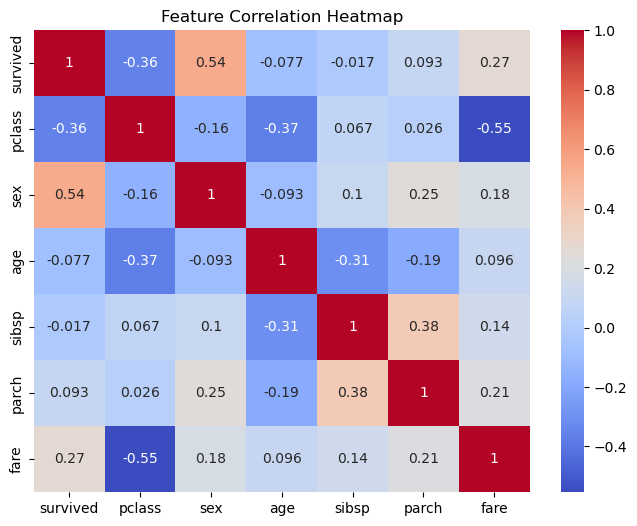

In [23]:
#Heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
#Drop rows with missing values in relevant columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()

#Encode categorical variables
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

#Define variables and target
X = df.drop('survived', axis=1)
y = df['survived']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#Fit KNN
k = 8  
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=8)

In [42]:
#Predictions
y_pred = knn.predict(X_test_scaled)

results = pd.DataFrame({
    'Actual Survived': y_test.values,
    'Predicted Survived': y_pred
})
print(results.head(10))

   Actual Survived  Predicted Survived
0                0                   0
1                1                   1
2                1                   1
3                1                   1
4                0                   0
5                1                   1
6                1                   0
7                1                   1
8                0                   0
9                0                   1


In [21]:
#Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[75 12]
 [17 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84        87
           1       0.76      0.70      0.73        56

    accuracy                           0.80       143
   macro avg       0.79      0.78      0.78       143
weighted avg       0.80      0.80      0.80       143

Accuracy: 0.7972027972027972


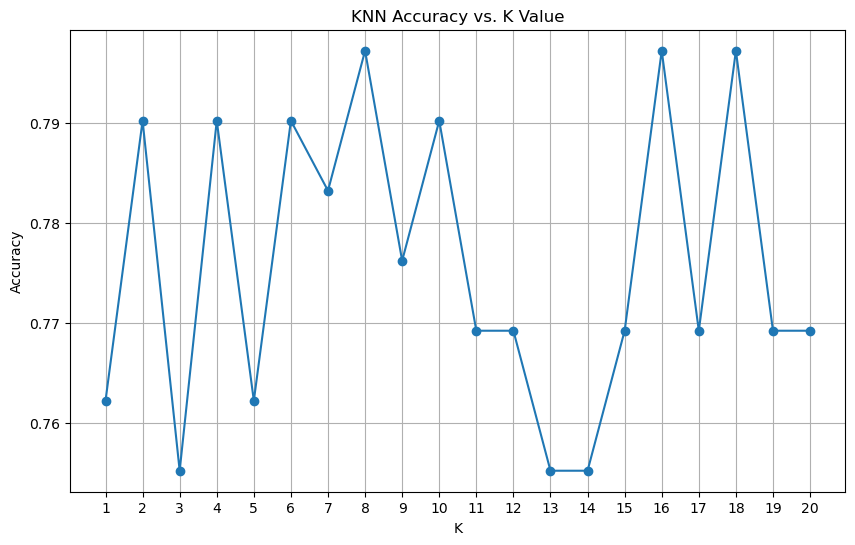

In [15]:
#Try different k values and plot accuracy
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

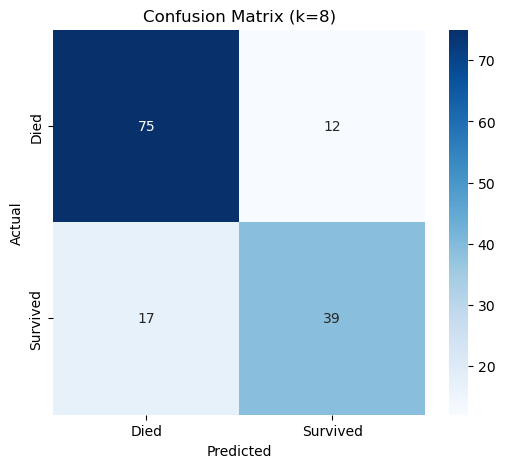

In [25]:
#Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (k={k})')
plt.show()

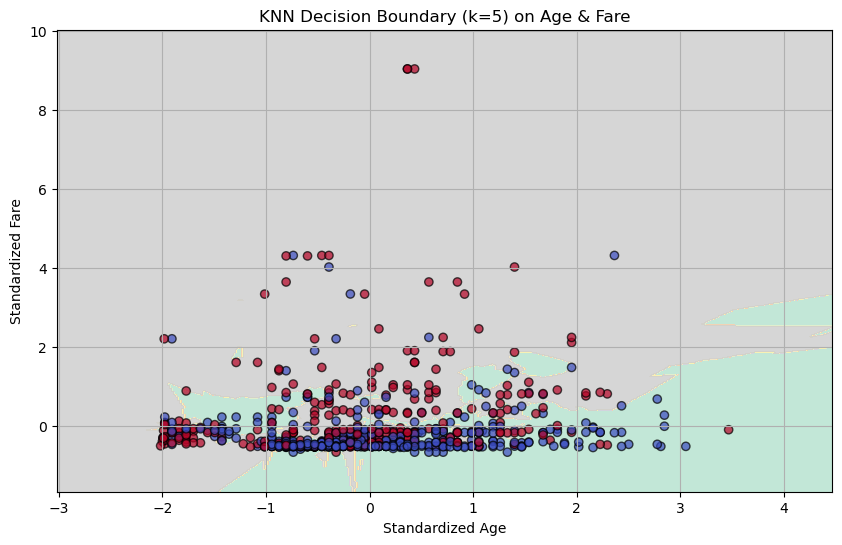

In [31]:
#Recreate a 2D version of X using only 'age' and 'fare'
X2D = df[['age', 'fare']]
X2D_scaled = scaler.fit_transform(X2D)
y = df['survived']

#Split into train and test 
X2D_train, X2D_test, y_train, y_test = train_test_split(X2D_scaled, y, test_size=0.2, random_state=42)

#Train KNN 
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X2D_train, y_train)

#Create meshgrid for plotting
h = 0.02
x_min, x_max = X2D_scaled[:, 0].min() - 1, X2D_scaled[:, 0].max() + 1
y_min, y_max = X2D_scaled[:, 1].min() - 1, X2D_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

#Predict across mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel2, alpha=0.8)
plt.scatter(X2D_scaled[:, 0], X2D_scaled[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm, alpha=0.7)
plt.xlabel('Standardized Age')
plt.ylabel('Standardized Fare')
plt.title(f'KNN Decision Boundary (k={k}) on Age & Fare')
plt.grid(True)
plt.show()

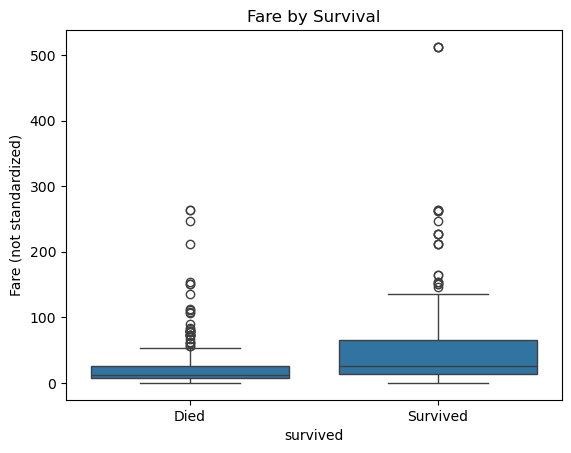

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='survived', y='fare')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.title('Fare by Survival')
plt.ylabel('Fare (not standardized)')
plt.show()